In [1]:
pip install pandas numpy matplotlib scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.


2026-05-05 14:55:05,257 - INFO - 
📥 STEP 1: LOADING DATA
2026-05-05 14:55:05,258 - INFO - 📥 Downloading energy data from GitHub...



⚡ POWER CONSUMPTION FORECASTING WITH ARIMA


2026-05-05 14:55:37,268 - WARNING - ⚠️ Could not download data: <urlopen error [Errno -3] Temporary failure in name resolution>
2026-05-05 14:55:37,269 - INFO - 📝 Creating synthetic energy data...
2026-05-05 14:55:37,274 - INFO - ✅ Synthetic data created: 26281 records
2026-05-05 14:55:37,274 - INFO - 
📊 STEP 2: EXPLORATORY DATA ANALYSIS
2026-05-05 14:55:37,275 - INFO - 
2026-05-05 14:55:37,276 - INFO - EXPLORATORY DATA ANALYSIS
2026-05-05 14:55:37,277 - INFO - ============================================================



📊 Dataset Overview:
  • Shape: (26281, 1)
  • Time period: 2012-01-01 00:00:00 to 2014-12-31 00:00:00
  • Missing values: 0

📈 Statistical Summary:
           load
count 26,281.00
mean   3,100.78
std      428.31
min    1,966.46
25%    2,776.25
50%    3,102.67
75%    3,423.20
max    4,205.20


2026-05-05 14:55:39,812 - INFO - ✅ EDA report saved as '01_eda_report.png'


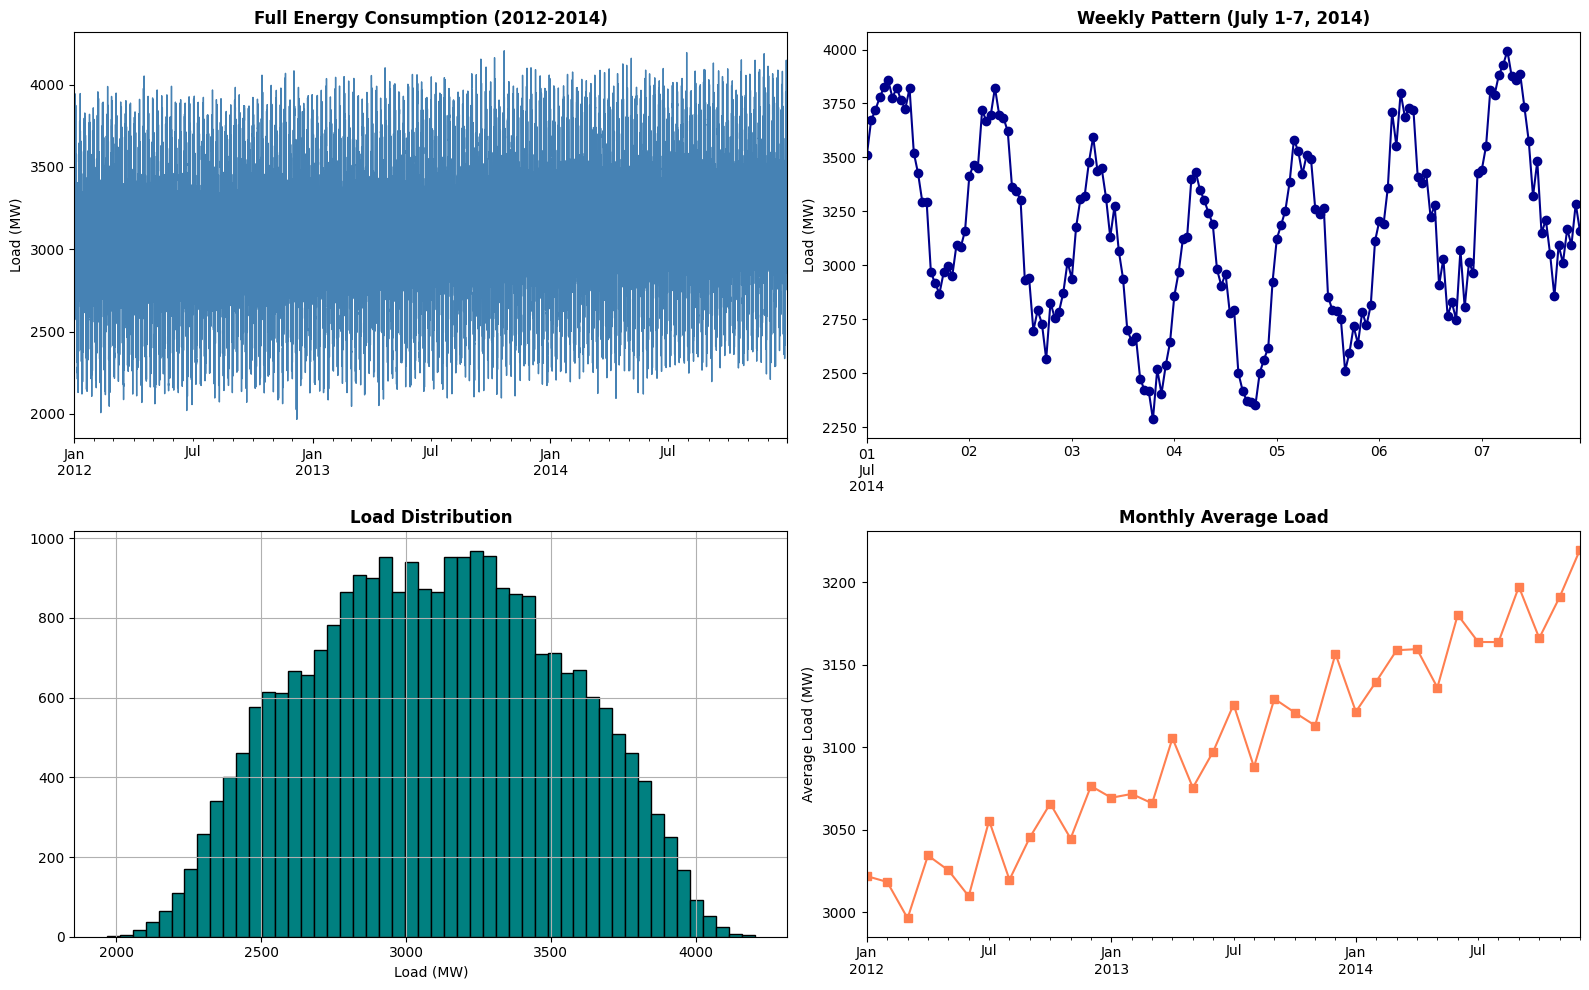

2026-05-05 14:55:40,412 - INFO - 
🏗️ STEP 3: INITIALIZING FORECASTING MODEL
2026-05-05 14:55:40,413 - INFO - ✅ ARIMAForecaster initialized with order=(2, 1, 0), seasonal_order=(1, 1, 0, 24)
2026-05-05 14:55:40,414 - INFO - 
🔀 STEP 4: PREPARING DATA
2026-05-05 14:55:40,414 - INFO - 🔀 Preparing train/test split...
2026-05-05 14:55:40,421 - INFO -   • Train shape: (22338, 1)
2026-05-05 14:55:40,422 - INFO -   • Test shape: (3943, 1)
2026-05-05 14:55:40,423 - INFO - 
🚀 STEP 5: TRAINING MODEL
2026-05-05 14:55:40,424 - INFO - 🏗️ Training ARIMA model...
2026-05-05 14:56:32,770 - INFO - ✅ Model training complete!
2026-05-05 14:56:32,874 - INFO - 
✅ STEP 6: WALK-FORWARD VALIDATION
2026-05-05 14:56:32,875 - INFO - 🚶 Running walk-forward validation (horizon=3, window=720)...


                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                22338
Model:             SARIMAX(2, 1, 0)x(1, 1, 0, 24)   Log Likelihood               29682.449
Date:                            Tue, 05 May 2026   AIC                         -59356.897
Time:                                    14:56:32   BIC                         -59324.845
Sample:                                01-01-2012   HQIC                        -59346.466
                                     - 07-19-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6504      0.006   -102.846      0.000      -0.663      -0.638
ar.L2         -0.3245      0.006   

In [ ]:
"""
POWER CONSUMPTION FORECASTING WITH ARIMA
==========================================
A production-ready machine learning project demonstrating:
✓ Data preprocessing & EDA
✓ Time series modeling (ARIMA/SARIMA)
✓ Model evaluation & validation
✓ Visualization & reporting
✓ Error handling & logging

Author: [Your Name]
Date: 2026
"""

import os
import warnings
import logging
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math
import urllib.request
import io
from pathlib import Path

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

%matplotlib inline
pd.options.display.float_format = '{:,.2f}'.format
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

# ============================================
# 1. DATA LOADING & PREPROCESSING
# ============================================

class DataLoader:
    """Handles data loading from GitHub or creates synthetic data"""
    
    @staticmethod
    def load_energy_data():
        """Load real energy data from GitHub"""
        url = "https://raw.githubusercontent.com/microsoft/ML-For-Beginners/main/7-TimeSeries/2-ARIMA/data/energy.csv"
        
        try:
            logger.info("📥 Downloading energy data from GitHub...")
            with urllib.request.urlopen(url) as response:
                data = response.read()
            
            energy = pd.read_csv(io.BytesIO(data), index_col=0, parse_dates=True)
            energy = energy[['load']]
            logger.info(f"✅ Data loaded: {energy.shape[0]} records, {energy.shape[1]} columns")
            return energy
            
        except Exception as e:
            logger.warning(f"⚠️ Could not download data: {e}")
            logger.info("📝 Creating synthetic energy data...")
            return DataLoader.create_synthetic_data()
    
    @staticmethod
    def create_synthetic_data():
        """Create realistic synthetic power data"""
        dates = pd.date_range('2012-01-01', '2014-12-31', freq='H')
        np.random.seed(42)
        
        # Realistic power pattern
        base_load = 3000
        daily_pattern = 500 * np.sin(np.arange(len(dates)) * 2 * np.pi / 24)
        weekly_pattern = 300 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24*7))
        trend = np.linspace(0, 200, len(dates))
        noise = np.random.normal(0, 100, len(dates))
        
        load_values = base_load + daily_pattern + weekly_pattern + trend + noise
        energy = pd.DataFrame({'load': np.maximum(load_values, 1000)}, index=dates)
        
        logger.info(f"✅ Synthetic data created: {energy.shape[0]} records")
        return energy

# ============================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

class EDA:
    """Exploratory Data Analysis"""
    
    @staticmethod
    def generate_report(energy):
        """Generate comprehensive EDA report"""
        logger.info("\n" + "="*60)
        logger.info("EXPLORATORY DATA ANALYSIS")
        logger.info("="*60)
        
        print(f"\n📊 Dataset Overview:")
        print(f"  • Shape: {energy.shape}")
        print(f"  • Time period: {energy.index[0]} to {energy.index[-1]}")
        print(f"  • Missing values: {energy.isnull().sum().sum()}")
        print(f"\n📈 Statistical Summary:")
        print(energy.describe())
        
        # Visualizations
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # Plot 1: Full time series
        energy['load'].plot(ax=axes[0, 0], color='steelblue', linewidth=1)
        axes[0, 0].set_title('Full Energy Consumption (2012-2014)', fontsize=12, fontweight='bold')
        axes[0, 0].set_ylabel('Load (MW)')
        
        # Plot 2: Zoom to 1 week
        energy['2014-07-01':'2014-07-07']['load'].plot(ax=axes[0, 1], color='darkblue', marker='o')
        axes[0, 1].set_title('Weekly Pattern (July 1-7, 2014)', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Load (MW)')
        
        # Plot 3: Distribution
        energy['load'].hist(ax=axes[1, 0], bins=50, color='teal', edgecolor='black')
        axes[1, 0].set_title('Load Distribution', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Load (MW)')
        
        # Plot 4: Monthly average
        monthly = energy.resample('M')['load'].mean()
        monthly.plot(ax=axes[1, 1], color='coral', marker='s')
        axes[1, 1].set_title('Monthly Average Load', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Average Load (MW)')
        
        plt.tight_layout()
        plt.savefig('01_eda_report.png', dpi=300, bbox_inches='tight')
        logger.info("✅ EDA report saved as '01_eda_report.png'")
        plt.show()
        
        return energy

# ============================================
# 3. TIME SERIES FORECASTING MODEL
# ============================================

class ARIMAForecaster:
    """ARIMA/SARIMA Time Series Forecasting Model"""
    
    def __init__(self, order=(2, 1, 0), seasonal_order=(1, 1, 0, 24)):
        self.order = order
        self.seasonal_order = seasonal_order
        self.model = None
        self.results = None
        self.scaler = MinMaxScaler()
        self.train_data = None
        self.test_data = None
        logger.info(f"✅ ARIMAForecaster initialized with order={order}, seasonal_order={seasonal_order}")
    
    def prepare_data(self, energy, train_ratio=0.8):
        """Split and scale data"""
        logger.info("🔀 Preparing train/test split...")
        
        # Split data
        split_idx = int(len(energy) * train_ratio)
        train = energy[:split_idx].copy()
        test = energy[split_idx:].copy()
        
        # Scale
        train['load'] = self.scaler.fit_transform(train[['load']])
        test['load'] = self.scaler.transform(test[['load']])
        
        self.train_data = train
        self.test_data = test
        
        logger.info(f"  • Train shape: {train.shape}")
        logger.info(f"  • Test shape: {test.shape}")
        
        return train, test
    
    def fit(self):
        """Fit ARIMA model"""
        logger.info("🏗️ Training ARIMA model...")
        try:
            self.model = SARIMAX(
                endog=self.train_data,
                order=self.order,
                seasonal_order=self.seasonal_order
            )
            self.results = self.model.fit(disp=False)
            logger.info("✅ Model training complete!")
            print(self.results.summary())
            return self.results
        except Exception as e:
            logger.error(f"❌ Model fitting failed: {e}")
            raise
    
    def forecast(self, steps=24):
        """Make predictions"""
        logger.info(f"🔮 Forecasting {steps} steps ahead...")
        try:
            forecast = self.results.get_forecast(steps=steps)
            forecast_df = forecast.conf_int()
            forecast_df['predictions'] = forecast.predicted_mean
            logger.info("✅ Forecast complete!")
            return forecast_df
        except Exception as e:
            logger.error(f"❌ Forecasting failed: {e}")
            raise
    
    def walk_forward_validation(self, horizon=3, window=720):
        """Walk-forward validation for robust evaluation"""
        logger.info(f"🚶 Running walk-forward validation (horizon={horizon}, window={window})...")
        
        history = list(self.train_data['load'])
        predictions = []
        actuals = []
        
        for i in range(len(self.test_data) - horizon + 1):
            # Keep rolling window
            if len(history) > window:
                history = history[-window:]
            
            try:
                model = SARIMAX(endog=history, order=self.order, seasonal_order=self.seasonal_order)
                model_fit = model.fit(disp=False)
                yhat = model_fit.forecast(steps=horizon)
                predictions.append(yhat.values)
                
                # Add actual observation
                actual = self.test_data['load'].iloc[i:i+horizon].values
                actuals.append(actual)
                
                history.extend(self.test_data['load'].iloc[i:i+1].values)
                
                if (i + 1) % max(1, (len(self.test_data) // 5)) == 0:
                    logger.info(f"  ✓ Progress: {i+1}/{len(self.test_data)}")
            except:
                continue
        
        logger.info(f"✅ Validation complete! ({len(predictions)} predictions)")
        return np.array(predictions), np.array(actuals)
    
    def save_model(self, filepath='arima_model.pkl'):
        """Save trained model"""
        with open(filepath, 'wb') as f:
            pickle.dump(self.results, f)
        logger.info(f"💾 Model saved to '{filepath}'")
    
    def load_model(self, filepath='arima_model.pkl'):
        """Load pre-trained model"""
        with open(filepath, 'rb') as f:
            self.results = pickle.load(f)
        logger.info(f"📂 Model loaded from '{filepath}'")

# ============================================
# 4. MODEL EVALUATION & METRICS
# ============================================

class ModelEvaluator:
    """Evaluate model performance"""
    
    @staticmethod
    def calculate_metrics(y_actual, y_pred):
        """Calculate comprehensive metrics"""
        mae = mean_absolute_error(y_actual, y_pred)
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
        mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
        r2 = r2_score(y_actual, y_pred)
        
        return {
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'R2': r2
        }
    
    @staticmethod
    def print_metrics(metrics, scaler=None):
        """Print evaluation metrics"""
        logger.info("\n" + "="*60)
        logger.info("MODEL EVALUATION METRICS")
        logger.info("="*60)
        
        print(f"\n📊 Performance Metrics:")
        print(f"  • Mean Absolute Error (MAE):        {metrics['MAE']:.4f}")
        print(f"  • Root Mean Squared Error (RMSE):   {metrics['RMSE']:.4f}")
        print(f"  • Mean Absolute % Error (MAPE):     {metrics['MAPE']:.2f}%")
        print(f"  • R² Score:                         {metrics['R2']:.4f}")
        
        print(f"\n🎯 Interpretation:")
        if metrics['MAPE'] < 2:
            print(f"  ✅ Excellent accuracy! ({metrics['MAPE']:.2f}% error)")
        elif metrics['MAPE'] < 5:
            print(f"  ✅ Good accuracy! ({metrics['MAPE']:.2f}% error)")
        elif metrics['MAPE'] < 10:
            print(f"  ⚠️ Moderate accuracy ({metrics['MAPE']:.2f}% error)")
        else:
            print(f"  ❌ Poor accuracy ({metrics['MAPE']:.2f}% error)")
        
        return metrics
    
    @staticmethod
    def plot_results(y_actual, y_pred, title="Model Performance"):
        """Visualize predictions vs actuals"""
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot 1: Time series comparison
        axes[0].plot(y_actual, label='Actual', color='red', linewidth=2, marker='o')
        axes[0].plot(y_pred, label='Predicted', color='blue', linewidth=2, linestyle='--')
        axes[0].set_title(f'{title}', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Load (Scaled)')
        axes[0].legend(fontsize=11)
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Residuals
        residuals = y_actual - y_pred
        axes[1].plot(residuals, color='purple', linewidth=1, marker='.')
        axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
        axes[1].set_title('Prediction Errors (Residuals)', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Error (Actual - Predicted)')
        axes[1].set_xlabel('Time Step')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('02_model_evaluation.png', dpi=300, bbox_inches='tight')
        logger.info("✅ Evaluation plots saved as '02_model_evaluation.png'")
        plt.show()

# ============================================
# 5. MAIN EXECUTION
# ============================================

def main():
    """Main project execution"""
    
    print("\n" + "="*70)
    print("⚡ POWER CONSUMPTION FORECASTING WITH ARIMA")
    print("="*70)
    
    # 1. Load data
    logger.info("\n📥 STEP 1: LOADING DATA")
    loader = DataLoader()
    energy = loader.load_energy_data()
    
    # 2. EDA
    logger.info("\n📊 STEP 2: EXPLORATORY DATA ANALYSIS")
    eda = EDA()
    energy = eda.generate_report(energy)
    
    # 3. Initialize forecaster
    logger.info("\n🏗️ STEP 3: INITIALIZING FORECASTING MODEL")
    forecaster = ARIMAForecaster(order=(2, 1, 0), seasonal_order=(1, 1, 0, 24))
    
    # 4. Prepare data
    logger.info("\n🔀 STEP 4: PREPARING DATA")
    train, test = forecaster.prepare_data(energy, train_ratio=0.85)
    
    # 5. Train model
    logger.info("\n🚀 STEP 5: TRAINING MODEL")
    forecaster.fit()
    
    # 6. Validate
    logger.info("\n✅ STEP 6: WALK-FORWARD VALIDATION")
    predictions, actuals = forecaster.walk_forward_validation(horizon=3, window=720)
    
    # 7. Flatten arrays for metrics
    y_pred_flat = predictions.flatten()
    y_actual_flat = actuals.flatten()
    
    # Remove any NaN values
    valid_idx = ~(np.isnan(y_pred_flat) | np.isnan(y_actual_flat))
    y_pred_clean = y_pred_flat[valid_idx]
    y_actual_clean = y_actual_flat[valid_idx]
    
    # 8. Evaluate
    logger.info("\n📈 STEP 7: MODEL EVALUATION")
    evaluator = ModelEvaluator()
    metrics = evaluator.calculate_metrics(y_actual_clean, y_pred_clean)
    evaluator.print_metrics(metrics)
    
    # 9. Visualize
    logger.info("\n📊 STEP 8: VISUALIZATION")
    evaluator.plot_results(y_actual_clean, y_pred_clean)
    
    # 10. Save model
    logger.info("\n💾 STEP 9: SAVING MODEL")
    forecaster.save_model()
    
    logger.info("\n" + "="*70)
    logger.info("✅ PROJECT COMPLETE!")
    logger.info("="*70)
    
    return forecaster, metrics

# Run the project
if __name__ == "__main__":
    forecaster, metrics = main()